Đang chạy thực nghiệm với init='random'...
Đang chạy thực nghiệm với init='k-means++'...


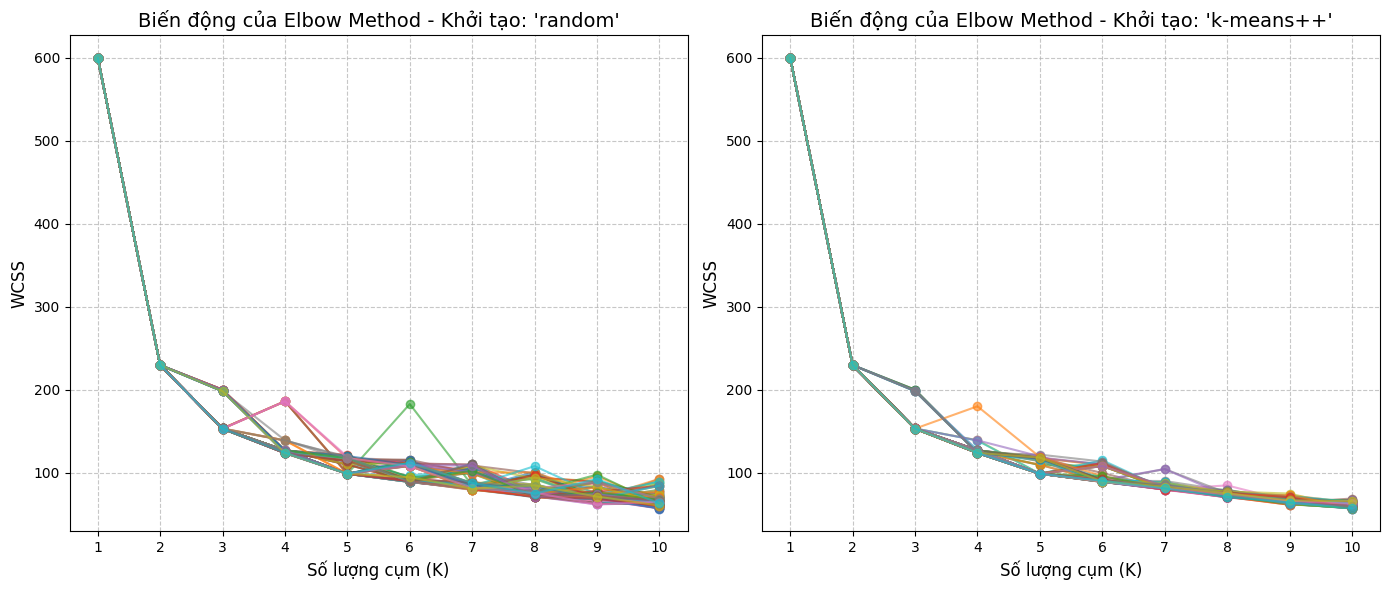

In [7]:

import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)
from src.models import run_kmeans_multiple_times


# 1. Đọc dữ liệu từ file thực tế của bạn
df = pd.read_csv('../data/Đã xử lí/scaled_iris.csv')

# 2. Xóa bỏ cột 'species' chứa chữ, chỉ lấy giá trị (values) của 4 cột số còn lại
X = df.drop(columns=['species']).values

# 3. Cấu hình tham số cho thực nghiệm
k_range = range(1, 11)
n_runs = 100

# 4. Chạy thực nghiệm K-Means
print("Đang chạy thực nghiệm với init='random'...")
wcss_random = run_kmeans_multiple_times(X, k_range, n_runs=n_runs, init_method='random')

print("Đang chạy thực nghiệm với init='k-means++'...")
wcss_kmeans_plus = run_kmeans_multiple_times(X, k_range, n_runs=n_runs, init_method='k-means++')

# 5. Khối code vẽ đồ thị (bạn dùng lại đoạn code plt.figure... mình đã gửi ở trên nhé)
# Vẽ đồ thị so sánh trực quan 
plt.figure(figsize=(14, 6))

# Vẽ đồ thị cho phương pháp 'random'
plt.subplot(1, 2, 1)
for i in range(n_runs):
    plt.plot(k_range, wcss_random[i], marker='o', alpha=0.6)
plt.title("Biến động của Elbow Method - Khởi tạo: 'random'", fontsize=14)
plt.xlabel("Số lượng cụm (K)", fontsize=12)
plt.ylabel("WCSS", fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)

# Vẽ đồ thị cho phương pháp 'k-means++'
plt.subplot(1, 2, 2)
for i in range(n_runs):
    plt.plot(k_range, wcss_kmeans_plus[i], marker='o', alpha=0.6)
plt.title("Biến động của Elbow Method - Khởi tạo: 'k-means++'", fontsize=14)
plt.xlabel("Số lượng cụm (K)", fontsize=12)
plt.ylabel("WCSS", fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()